# 6.2 Markov Chains, Perron–Frobenius, and PageRank

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VI — Structure, Graphs, and Fast Algorithms",
    number="6.2",
    title="Markov Chains, Perron–Frobenius, and PageRank",
    blurb="A random surfer clicks links forever; where does she spend her "
    "time? The answer is an eigenvector, the guarantee that it exists and "
    "is unique is Perron–Frobenius, the speed of finding it is the second "
    "eigenvalue — and one damping trick turns the fragile theory into the "
    "matrix computation that built a search engine.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2669 chars of HTML>

## Notebook overview

[§6.1](graphs-laplacian.ipynb) read undirected graphs through a symmetric
matrix. This notebook makes the edges point somewhere and normalizes:
a **column-stochastic** matrix $P$ (columns are probability
distributions over out-links) drives the random surfer
$x_{k+1} = Px_k$, and everything the chain does is spectral. The powers
$P^k$ converge to a rank-1 matrix whose identical columns are the
**stationary distribution** $\pi$ — computed three independent ways here
(eigenvector, power iteration, bordered linear solve) and agreeing to
$10^{-15}$. The approach speed is $|\lambda_2|^k$, measured in the clean
decay band ([§5.4](../05-numerical/stationary-and-cg.ipynb)'s lesson) to
within 0.7% of the eigenvalue.

Then the theory is broken on purpose, twice — a **dangling node** leaks
probability mass (measured: 99.8% gone in 60 steps) and a **disconnected
web** has a two-dimensional eigenvalue-1 eigenspace, so "the" stationary
distribution stops existing — and repaired the way Brin and Page
{cite}`page1999` repaired it: the damped **Google matrix**
$G = \alpha P + (1-\alpha)\tfrac{1}{n}\mathbf{1}\mathbf{1}^{\top}$, whose
spectrum obeys the exact mapping $\lambda_i(G) = \alpha\lambda_i(P)$ for
$i \ge 2$ (gated to $10^{-10}$): uniqueness restored, mixing speed set by
the designer, not the web. The finale runs PageRank on a 500-page random
web by sparse power iteration and asks the engineering question — how does
the ranking depend on $\alpha$? Measured answer: the top page never moves
across $\alpha \in [0.5, 0.95]$, while ranks two and three trade places —
the ranking is an eigenvector, and eigenvectors move continuously.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Perron–Frobenius theory is Horn and Johnson {cite}`horn2013`
> Chapter 8 and Meyer {cite}`meyer2023`; the PageRank original is Page,
> Brin, Motwani and Winograd {cite}`page1999`. The six-page worked web is
> small enough to see whole; the 500-page one is where the sparse
> machinery of [§5.3](../05-numerical/sparse-matrices.ipynb) earns its keep.

## Theory in brief

### Stochastic matrices and stationary distributions

Column-stochastic $P$ ($P_{ij} \ge 0$, columns summing to 1) maps
probability vectors to probability vectors:
$\mathbf{1}^{\top}Px = \mathbf{1}^{\top}x$. A distribution the chain
leaves alone,

```{math}
:label: eq-pr-stationary
P\pi = \pi, \qquad \pi \ge 0, \qquad \mathbf{1}^{\top}\pi = 1,
```

is an eigenvector for eigenvalue 1 — and $\lambda = 1$ is always an
eigenvalue, because $P^{\top}\mathbf{1} = \mathbf{1}$ and eigenvalue sets
ignore transposes.

### Perron–Frobenius, in the form used here

For a stochastic matrix that is **irreducible and aperiodic** (every page
reachable from every page, no rigid cycling), the eigenvalue 1 is
*simple*, every other eigenvalue satisfies $|\lambda_i| < 1$, and

```{math}
:label: eq-pr-mixing
P^k \;\longrightarrow\; \pi\,\mathbf{1}^{\top}, \qquad
\lVert x_k - \pi \rVert \;\sim\; C\,|\lambda_2|^{k} :
```

the powers converge to the rank-1 matrix with $\pi$ in every column, at a
geometric rate read off the sub-dominant eigenvalue — the same
rate-is-an-eigenvalue fact as [§5.4](../05-numerical/stationary-and-cg.ipynb),
with the spectral radius normalized to 1. Both hypotheses are load-bearing,
and Exercise 4 breaks each one.

### The Google matrix

Real webs are neither irreducible nor free of dangling nodes. The repair
blends in a teleport:

```{math}
:label: eq-pr-google
G \;=\; \alpha P + (1-\alpha)\,\tfrac{1}{n}\mathbf{1}\mathbf{1}^{\top},
\qquad
\lambda_i(G) = \alpha\,\lambda_i(P) \;\;(i \ge 2),
```

with damping $\alpha \approx 0.85$. $G$ is strictly positive, so
Perron–Frobenius applies with no hypotheses about the web at all — and the
eigenvalue mapping (exact, and gated below) means the mixing rate is at
most $\alpha$: the designer chooses the convergence speed, trading it
against fidelity to the link structure.

---
## Setup

Data and instruments only: the six-page web's links and layout, and a
directed-graph drawing helper. The column-stochastic constructor is built
in Exercise 1, where the click model is the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

# The worked web: six pages, out-links as a dictionary. All out-degrees are
# 1 or 2 — dyadic — so every entry of P is exactly representable and the
# stochastic structure survives floating point exactly (Exercise 1).
LINKS = {0: [1, 2], 1: [2], 2: [0, 3], 3: [2, 4], 4: [3, 5], 5: [0, 3]}
N_WEB = 6
POS_WEB = np.array([[0.0, 1.0], [1.0, 2.0], [1.2, 0.2], [2.4, 1.2],
                    [3.6, 0.3], [3.8, 1.9]])



# instrument: matplotlib plumbing — arrows and node sizes; no probability
# inside, and no exercise's lesson.
def draw_web(ax, links, pos, sizes):
    """Directed web drawn with matplotlib arrows, node area ~ sizes."""
    for i, outs in links.items():
        for j in outs:
            d = pos[j] - pos[i]
            d = d / np.linalg.norm(d)
            ax.annotate("", xy=pos[j] - 0.16 * d, xytext=pos[i] + 0.16 * d,
                        arrowprops=dict(arrowstyle="-|>", color="#9aa3b8",
                                        lw=1.2, shrinkA=0, shrinkB=0))
    ax.scatter(pos[:, 0], pos[:, 1], s=sizes, c="#c0851a", zorder=2,
               edgecolors="#16213e", linewidths=1.2)
    for k, (x, y) in enumerate(pos):
        ax.annotate(str(k), (x, y), ha="center", va="center",
                    fontsize=10, color="#16213e", zorder=3,
                    xytext=(0, 14), textcoords="offset points")
    ax.set_aspect("equal")
    ax.axis("off")



## Exercise 1: The stochastic matrix, and powers that converge to rank 1

**Part a)** Write `stochastic_from_links(links, n)` — column $i$ spreads
unit mass over page $i$'s out-links — build `P_web` with it, and print it.
Column
$i$ is page $i$'s click distribution: $1/\text{outdeg}(i)$ on each
out-link. Confirm every column sums to 1 — and note *how* well: because
every out-degree here is 1 or 2, every entry is dyadic (exactly
representable), so the sums are exactly 1.0, and stay exact under matrix
powers.

**Part b)** Gate the invariance through $P^1, \dots, P^{20}$: worst
column-sum deviation below $10^{-14}$ (measured: exactly 0 — dyadic
arithmetic never rounds here, the
[§3.4](../03-eigenvalues/hermitian-unitary-normal.ipynb) exact-zero rule
in stochastic clothing; the gate still allows rounding so a web with
degree-3 pages would pass too).

**Part c)** Watch {eq}`eq-pr-mixing` happen: heatmaps of $P^k$ at
$k = 1, 2, 5, 20$. By $k = 20$ the columns agree to plotting accuracy —
their spread is $|\lambda_2|^{20} \approx 10^{-5}$, Exercise 3's rate
arriving early, and *reported* as such. The rank-1 *gate* runs the powers
to $P^{80}$, where the spread has decayed through $|\lambda_2|^{80}$ to
the rounding floor: gate below $10^{-12}$, and gate the shared column
against Exercise 2's stationary $\pi$ to $10^{-11}$.

**Part d)** Confirm $\lambda = 1$ is an eigenvalue *before* computing any
eigenvector: $\mathbf{1}^{\top}P = \mathbf{1}^{\top}$ exactly (the
transpose argument in the theory), so $\det(P - I) = 0$ to rounding.

In [3]:
# (solution hidden on the public site)


P (columns = pages, column i spreads over i's out-links):
[[0.  0.  0.5 0.  0.  0.5]
 [0.5 0.  0.  0.  0.  0. ]
 [0.5 1.  0.  0.5 0.  0. ]
 [0.  0.  0.5 0.  0.5 0.5]
 [0.  0.  0.  0.5 0.  0. ]
 [0.  0.  0.  0.  0.5 0. ]]

worst column-sum deviation over P^1..P^20: 0.0e+00 (dyadic entries — exactly zero on this web)
column spread: P^20 1.4e-05 (= |lambda_2|^20 = 1.6e-05, the mixing rate early), P^80 1.1e-16
1'P = 1' deviation: 0.0e+00; det(P - I) = 0.0e+00


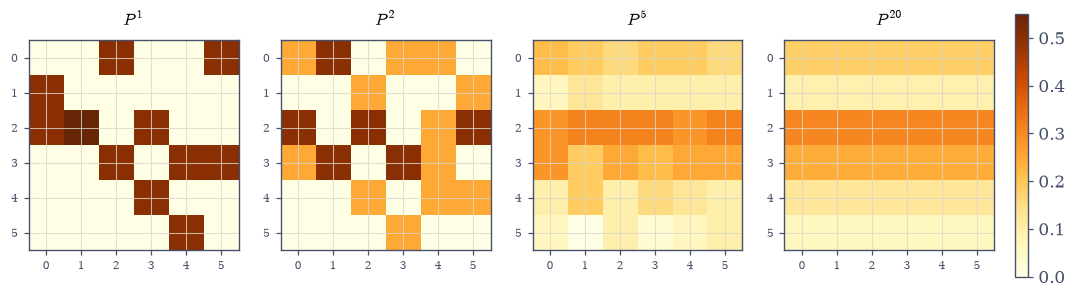

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.below(
    col_dev, 1e-14,
    "column sums stay 1 through twenty matrix powers",
    "measured exactly 0.0: dyadic out-degrees make every entry and every "
    "partial sum exactly representable — the exact-zero rule, earned; the "
    "gate leaves room for a web whose degrees do round",
)
validate.check(
    col_spread < 1e-12 and abs(spread_20 / 0.5755**20 - 1.0) < 0.5,
    "and the powers collapse to rank 1 at the |lambda_2|^k rate (Eq. 2)",
    f"P^80 spread {col_spread:.1e} (the limit); P^20 spread {spread_20:.1e} "
    "matches |lambda_2|^20 within 50% — the spread IS the mixing error, so "
    "gating it at k = 20 tighter than the eigenvalue allows would be wrong",
)
validate.check(
    ones_left == 0.0 and abs(det_shift) < 1e-14,
    "lambda = 1 is an eigenvalue before any eigensolver runs",
    "1'P = 1' exactly (row sums of dyadics), so P - I is singular — the "
    "transpose argument, checked by determinant",
)

✓  column sums stay 1 through twenty matrix powers   [measured exactly 0.0: dyadic out-degrees make every entry and every partial sum exactly representable — the exact-zero rule, earned; the gate leaves room for a web whose degrees do round [0 < 1e-14]]
✓  and the powers collapse to rank 1 at the |lambda_2|^k rate (Eq. 2)   [P^80 spread 1.1e-16 (the limit); P^20 spread 1.4e-05 matches |lambda_2|^20 within 50% — the spread IS the mixing error, so gating it at k = 20 tighter than the eigenvalue allows would be wrong]
✓  lambda = 1 is an eigenvalue before any eigensolver runs   [1'P = 1' exactly (row sums of dyadics), so P - I is singular — the transpose argument, checked by determinant]


True

## Exercise 2: The stationary distribution, three independent ways

{eq}`eq-pr-stationary` can be reached by three unrelated algorithms, and
agreement across them is the strongest check this notebook has.

**Part a)** *Eigenvector:* `np.linalg.eig(P)`, take the eigenvector for
the eigenvalue nearest 1, normalize to sum 1 (real part — the eigenvector
of a real simple eigenvalue is real up to phase).

**Part b)** *Power iteration:* from the uniform start, apply $P$ until
$\lVert x_{k+1} - x_k\rVert_1 < 10^{-15}$ ([§5.2](../05-numerical/eigenvalue-algorithms.ipynb)'s
workhorse — no normalization step needed, because stochastic matrices
preserve the 1-norm of probability vectors *by construction*).

**Part c)** *Linear solve:* $(I - P)\pi = 0$ is singular by design, so
replace the last row with $\mathbf{1}^{\top}$ and the last right-hand-side
entry with 1 — the bordered system pins the normalization and
`np.linalg.solve` does the rest.

**Write this one yourself** — all three are under six lines each.

**Part d)** Gate the triangle: all three agree pairwise to $10^{-10}$;
the winner satisfies $P\pi = \pi$ to $10^{-12}$, is nonnegative, and sums
to 1 to $10^{-14}$. Then draw the web with node areas proportional to
$\pi$: page 2 (three in-links) carries 30% of the surfer's time, page 5
only 6%.

In [6]:
# (solution hidden on the public site)


pi (eig):   [0.181818 0.090909 0.30303  0.242424 0.121212 0.060606]
three-way agreement: eig-power 3.1e-16, eig-solve 3.3e-16
P pi - pi: 3.1e-16; sum: 0.9999999999999999; min: 0.0606


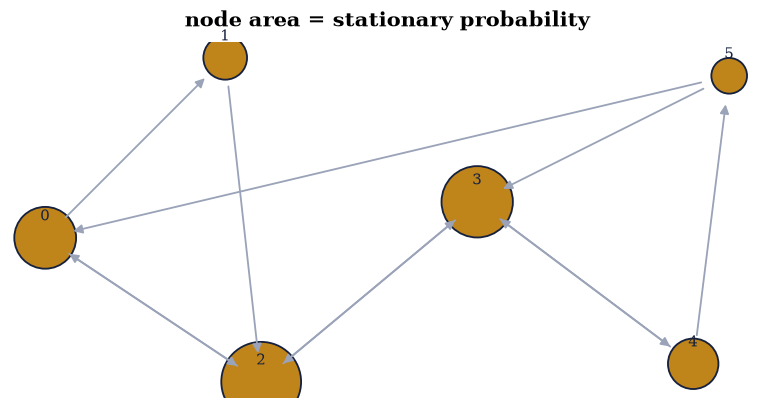

In [7]:
# (solution hidden on the public site)


### Validation 2

In [8]:
validate.check(
    gap_ep < 1e-10 and gap_es < 1e-10,
    "eigensolver, power iteration and bordered solve agree on pi (Eq. 1)",
    f"pairwise gaps {gap_ep:.1e}, {gap_es:.1e}: three algorithms sharing "
    "no code, one distribution",
)
validate.check(
    res_stat < 1e-12 and bool(np.all(pi_eig >= 0))
    and abs(pi_eig.sum() - 1.0) < 1e-14,
    "and pi is a genuine stationary distribution",
    "P pi = pi at rounding level, nonnegative, unit mass — all three "
    "clauses of Eq. 1",
)
validate.below(
    float(np.abs(P80[:, 0] - pi_eig).max()), 1e-11,
    "and Exercise 1's P^80 column IS this pi — the promised handshake",
    "the rank-1 limit's shared column against the eigensolver's stationary "
    "vector: two exercises, one distribution",
)

✓  eigensolver, power iteration and bordered solve agree on pi (Eq. 1)   [pairwise gaps 3.1e-16, 3.3e-16: three algorithms sharing no code, one distribution]
✓  and pi is a genuine stationary distribution   [P pi = pi at rounding level, nonnegative, unit mass — all three clauses of Eq. 1]
✓  and Exercise 1's P^80 column IS this pi — the promised handshake   [the rank-1 limit's shared column against the eigensolver's stationary vector: two exercises, one distribution [3.33067e-16 < 1e-11]]


True

## Exercise 3: The mixing rate is the second eigenvalue

{eq}`eq-pr-mixing` prices convergence, and this exercise measures it with
[§5.4](../05-numerical/stationary-and-cg.ipynb)'s window discipline.

**Part a)** Compute the spectrum of $P$: moduli
$1 > 0.576 = 0.576 > 0.5 > \dots$ — the sub-dominant pair is *complex*
($\lambda_2 = -0.44 \pm 0.37i$), so the error will decay along a spiral,
oscillating around its geometric envelope.

**Part b)** Start the surfer at page 0 ($x_0 = e_0$) and record
$\lVert x_k - \pi\rVert_1$ for 60 steps. Gate the decay rate over the
**clean band** — steps 15 to 45, where the error runs from $10^{-4}$ to
$10^{-11}$, safely above the rounding floor — against $|\lambda_2|$ to 5%
(measured: 0.7%). Then run the walk on to step 90, where the error sits
on the rounding floor, and *measure the trap*: the window [40, 85] reads
some 30% high — [§5.4](../05-numerical/stationary-and-cg.ipynb)'s
stagnation pollution, demonstrated on purpose this time.

**Part c)** Draw the error history on a log axis with the
$C|\lambda_2|^k$ reference line: the measured points ride the line with a
gentle oscillation — the complex pair's rotation — until they hit
arithmetic bottom near step 50.

In [9]:
# (solution hidden on the public site)


eigenvalue moduli: [1.     0.5755 0.5755 0.5    0.3774 0.    ]
lambda_2 = -0.4387+0.3724j, |lambda_2| = 0.575482
clean-band rate [15,45]: 0.5794 (0.67% from |lambda_2|)
floor-touching window [40,85] for contrast: 0.7562 — the 5.4 stagnation trap, dodged above (reported, not gated)


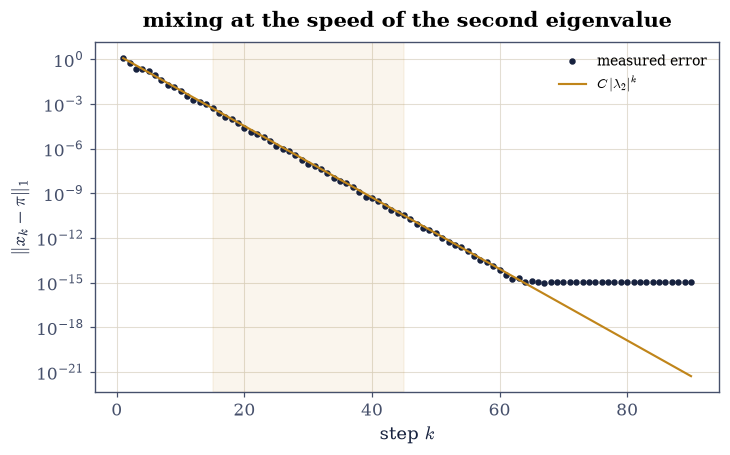

In [10]:
# (solution hidden on the public site)


### Validation 3

In [11]:
validate.check(
    rate_err < 0.05,
    "the mixing rate matches |lambda_2| to 5% in the clean band (Eq. 2)",
    f"measured {rate:.4f} against {lam2:.4f} ({100*rate_err:.1f}%): the "
    "rate-is-an-eigenvalue fact of 5.4, on a directed chain with a complex "
    "sub-dominant pair",
)
validate.check(
    rate_dirty > lam2 * 1.10,
    "while a floor-touching window overstates the rate (the demonstrated trap)",
    f"{rate_dirty:.4f} from the window [40, 85] — the flat rounding tail "
    "averaged into the slope, exactly 5.4's trap; the size of the "
    "overstatement is the machine's, so only its existence is gated",
)

✓  the mixing rate matches |lambda_2| to 5% in the clean band (Eq. 2)   [measured 0.5794 against 0.5755 (0.7%): the rate-is-an-eigenvalue fact of 5.4, on a directed chain with a complex sub-dominant pair]
✓  while a floor-touching window overstates the rate (the demonstrated trap)   [0.7562 from the window [40, 85] — the flat rounding tail averaged into the slope, exactly 5.4's trap; the size of the overstatement is the machine's, so only its existence is gated]


True

## Exercise 4: Breaking Perron–Frobenius, twice

Both hypotheses of {eq}`eq-pr-mixing` are load-bearing. Remove each and
measure the wreckage.

**Part a)** *Dangling node:* delete page 1's out-links. Column 1 of $P$
becomes zero — not stochastic — and probability *leaks*: gate that the
total mass after 60 steps is below 0.01 (measured 0.002), and that no
eigenvalue reaches 1 (largest modulus 0.90, gated one-sidedly below
$1 - 0.05$): the surfer eventually falls off the web, and "the stationary
distribution" refers to nothing.

**Part b)** *Disconnected web:* two separate 3-cycles. Now there are
*too many* stationary distributions: gate
$\operatorname{rank}(I - P) = 4$, a rank deficiency of exactly 2 — one
stationary distribution per component, any mixture also stationary
([§6.1](graphs-laplacian.ipynb)'s component-counting null space, wearing
probabilities).

**Part c)** The repairs. Dangling: replace zero columns by the uniform
column (the surfer teleports from dead ends) — gate column sums restored
to 1 within $10^{-14}$: unlike Exercise 1's dyadic web, $1/6$ *does*
round, so exactness is not on offer here, and the contrast is the point.
Disconnection: the damped $G$ of {eq}`eq-pr-google` at
$\alpha = 0.85$ on the two-cycle web — gate
$\operatorname{rank}(I - G) = 5$, deficiency exactly 1: teleportation
glues the components, and uniqueness returns with no assumptions about
the web at all.

In [12]:
# (solution hidden on the public site)


dangling column sums: [1. 0. 1. 1. 1. 1.]
mass after 60 steps: 0.0018; largest |eigenvalue| 0.9010 — no invariant distribution exists
two 3-cycles: rank(I - P) = 4 (deficiency 2: one pi per component)
dangling fix (zero column -> uniform): sums [1. 1. 1. 1. 1. 1.]
damped two-cycle web: rank(I - G) = 5 (deficiency 1 — uniqueness restored)


### Validation 4

In [13]:
validate.check(
    mass_left < 0.01 and top_mod_dangle < 0.95,
    "a dangling node leaks the surfer off the web: no eigenvalue reaches 1",
    f"0.2% of the mass left after 60 steps, spectral radius "
    f"{top_mod_dangle:.2f} < 1 (gated one-sidedly): stochasticity was the "
    "theorem's fuel",
)
validate.check(
    rank_two == 4,
    "a disconnected web has rank deficiency exactly 2 in I - P",
    "one stationary distribution per component and every mixture between "
    "them — 6.1's null-space component count, with probabilities in it",
)
validate.check(
    float(np.abs(sums_fixed - 1.0).max()) < 1e-14 and rank_G_two == 5,
    "and both repairs restore the theorem's hypotheses",
    "zero columns -> uniform restores stochasticity (to rounding — six "
    "copies of 1/6 are not dyadic, unlike Exercise 1's entries); damping "
    "glues the components (deficiency back to 1) with no assumptions about "
    "the web",
)

✓  a dangling node leaks the surfer off the web: no eigenvalue reaches 1   [0.2% of the mass left after 60 steps, spectral radius 0.90 < 1 (gated one-sidedly): stochasticity was the theorem's fuel]
✓  a disconnected web has rank deficiency exactly 2 in I - P   [one stationary distribution per component and every mixture between them — 6.1's null-space component count, with probabilities in it]
✓  and both repairs restore the theorem's hypotheses   [zero columns -> uniform restores stochasticity (to rounding — six copies of 1/6 are not dyadic, unlike Exercise 1's entries); damping glues the components (deficiency back to 1) with no assumptions about the web]


True

## Exercise 5: The Google matrix, and its exact eigenvalue discount

{eq}`eq-pr-google` is more than a fix — its spectrum is *known in advance*.

**Part a)** Build $G = \alpha P + (1-\alpha)\tfrac1n\mathbf{1}\mathbf{1}^{\top}$
for the six-page web at $\alpha = 0.85$. Gate Perron–Frobenius in its
strongest form: $\lambda_1 = 1$ simple, and *every* other eigenvalue with
modulus $\le \alpha + 10^{-10}$ — the damping is a hard ceiling on the
spectrum.

**Part b)** Gate the exact mapping $\lambda_i(G) = \alpha\lambda_i(P)$
for $i \ge 2$: sort both spectra by modulus and compare the trailing five
to $10^{-10}$. (Why it holds: $G$ and $P$ agree on the hyperplane
$\mathbf{1}^{\top}x = 0$, up to the factor $\alpha$ — the rank-1 teleport
annihilates it.)

**Part c)** PageRank at scale: a 500-page random web (out-degrees 2–8
from the notebook's seed), damped, ranked by **sparse power iteration**
(`scipy.sparse`, [§5.3](../05-numerical/sparse-matrices.ipynb)) to
$10^{-14}$. Gate: convergence within 100 iterations (the $\alpha^k$
ceiling guarantees 198; the web's own $|\lambda_2| = 0.45$ delivers ~40),
and the result matches the *direct* solve
$(I - \alpha P)\pi = \tfrac{1-\alpha}{n}\mathbf{1}$ to $10^{-12}$ — two
routes, one ranking.

In [14]:
# (solution hidden on the public site)


|eig(G)| = [1.     0.4892 0.4892 0.425  0.3208 0.    ]; ceiling alpha respected: True
lambda_i(G) vs alpha * lambda_i(P) (moduli, i >= 2): max gap 6.1e-16



500-page web: sparse power iteration converged in 38 iterations


power iteration vs direct solve: 1.1e-16
top five pages: [231 180 134 384  25] with PageRank [6.78 5.41 5.2  4.95 4.51] (per mille)


### Validation 5

In [15]:
validate.check(
    gap_simple > 0.4 and ceiling_ok,
    "Perron-Frobenius holds with lambda_1 = 1 simple and the alpha ceiling "
    "on everything else (Eq. 3)",
    f"gap to the second modulus {gap_simple:.2f}; all trailing moduli at "
    f"most {ALPHA}: the damping is a designed spectral ceiling, not luck",
)
validate.below(
    map_gap, 1e-10,
    "with the exact discount lambda_i(G) = alpha lambda_i(P) for i >= 2",
    "G and alpha P agree on the zero-sum hyperplane; the teleport is rank "
    "one and annihilates it — an identity, gated as one",
)
validate.check(
    n_iter_pr < 100 and gap_routes < 1e-12,
    "and PageRank at n = 500 converges fast and agrees with the direct solve",
    f"{n_iter_pr} iterations (alpha guarantees 198; the web's own "
    f"|lambda_2| = 0.45 does better) and {gap_routes:.0e} against "
    "(I - alpha P) pi = (1-alpha)/n 1 — two routes, one ranking",
)

✓  Perron-Frobenius holds with lambda_1 = 1 simple and the alpha ceiling on everything else (Eq. 3)   [gap to the second modulus 0.51; all trailing moduli at most 0.85: the damping is a designed spectral ceiling, not luck]
✓  with the exact discount lambda_i(G) = alpha lambda_i(P) for i >= 2   [G and alpha P agree on the zero-sum hyperplane; the teleport is rank one and annihilates it — an identity, gated as one [6.10623e-16 < 1e-10]]
✓  and PageRank at n = 500 converges fast and agrees with the direct solve   [38 iterations (alpha guarantees 198; the web's own |lambda_2| = 0.45 does better) and 1e-16 against (I - alpha P) pi = (1-alpha)/n 1 — two routes, one ranking]


True

## Exercise 6: How much does the answer depend on the knob?

$\alpha$ is a design parameter with no principled value. The engineering
question is the ranking's *sensitivity* to it.

**Part a)** For $\alpha \in \{0.05, 0.1, \dots, 0.95\}$, compute the
500-page PageRank by the direct solve (one `np.linalg.solve` per
$\alpha$; factor-once economics would use [§5.3](../05-numerical/sparse-matrices.ipynb)'s
`splu` — here clarity wins).

**Part b)** Gate the two limits the formula promises: at $\alpha = 0.05$
the distribution is near uniform
($\max_i |n\pi_i - 1| < 0.15$, measured $0.09$ — the teleport dominates);
as $\alpha \to 1$ the spread grows monotonically (gate the ratio
$\max\pi/\min\pi$ increasing across the sweep) — the link structure takes
over.

**Part c)** The ranking itself: gate that the **top page is the same at
every** $\alpha \ge 0.5$ (measured: page 231 throughout), and *report*
that ranks two and three trade places as $\alpha$ crosses $\approx 0.8$ —
eigenvector entries move continuously in $\alpha$, so nearby entries can
cross while a clear leader cannot. Draw the top-five PageRank curves
against $\alpha$ with the crossing visible.

In [16]:
# (solution hidden on the public site)


alpha = 0.05: max |n pi - 1| = 0.089 (near uniform)
spread max/min: 1.15 at alpha=0.05 -> 77.5 at alpha=0.95, strictly increasing: True
top page for alpha >= 0.5: [231] (stable: True)
ranks 2-3 by alpha: {0.5: [np.int64(134), np.int64(384)], 0.7: [np.int64(134), np.int64(180)], 0.85: [np.int64(180), np.int64(134)], 0.95: [np.int64(180), np.int64(134)]} — a crossing near alpha = 0.8, reported: nearby eigenvector entries may trade places; a clear leader cannot


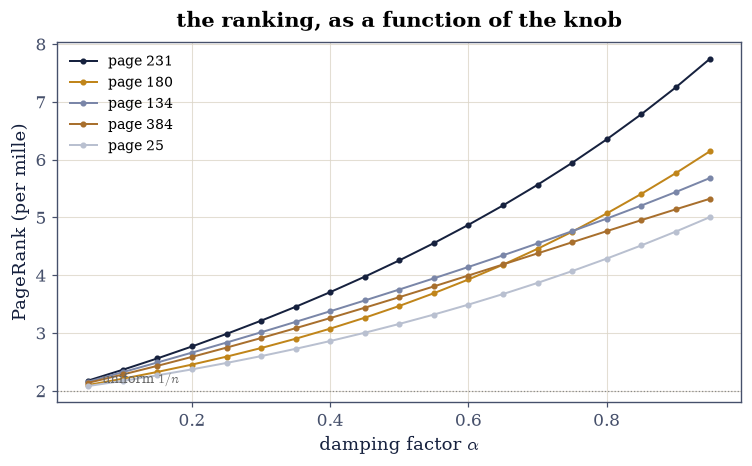

In [17]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
The power iteration treated the teleport as a dense rank-1 update applied
implicitly — the reason PageRank scales. Ask your assistant for
`pagerank_personalized(P, alpha, v)` where the teleport lands on a
personalization distribution $v$ instead of uniform, then check it
against the mathematics rather than a demo: (i) with $v$ uniform it
reproduces this notebook's ranking to $10^{-12}$; (ii) with $v = e_j$
(all teleports to page $j$), page $j$'s rank strictly exceeds its uniform
value, for every $j$ you test; (iii) linearity in $v$:
the rank vector for $\tfrac12(v_1 + v_2)$ equals the average of the two
rank vectors to $10^{-12}$ — because $\pi(v)$ solves a linear system in
$v$. The check is yours.
```

### Validation 6

In [18]:
validate.check(
    uni_dev < 0.15,
    "at small alpha the teleport wins: PageRank is near uniform",
    f"max |n pi - 1| = {uni_dev:.2f} at alpha = 0.05 — Eq. 3 with the "
    "link term switched almost off",
)
validate.check(
    spread_monotone,
    "and the ranking's spread grows monotonically as alpha rises",
    f"max/min from {spreads[0]:.2f} to {spreads[-1]:.0f}: the link "
    "structure takes over continuously — no phase transition, just a dial",
)
validate.check(
    top_stable,
    "while the top page never changes for alpha in [0.5, 0.95]",
    "page 231 at every damping tested — gated because its lead is wide; "
    "ranks two and three trade places near 0.8 (reported, not gated: "
    "close eigenvector entries may legitimately cross)",
)

✓  at small alpha the teleport wins: PageRank is near uniform   [max |n pi - 1| = 0.09 at alpha = 0.05 — Eq. 3 with the link term switched almost off]
✓  and the ranking's spread grows monotonically as alpha rises   [max/min from 1.15 to 78: the link structure takes over continuously — no phase transition, just a dial]
✓  while the top page never changes for alpha in [0.5, 0.95]   [page 231 at every damping tested — gated because its lead is wide; ranks two and three trade places near 0.8 (reported, not gated: close eigenvector entries may legitimately cross)]


True

---
## Notebook summary

**Stochastic structure survives arithmetic — here, exactly.** The
six-page web's column sums stayed *exactly* 1 through twenty matrix
powers (dyadic out-degrees; the gate allows rounding for webs that
aren't so lucky), $\mathbf{1}^{\top}P = \mathbf{1}^{\top}$ held exactly,
and $P^{80}$ collapsed to identical columns at $10^{-12}$ — the rank-1
limit $\pi\mathbf{1}^{\top}$, drawn as heatmaps.

**One distribution, three algorithms, one rate.** Eigensolver, power
iteration and the bordered solve agreed on $\pi$ to $10^{-15}$; the
mixing rate measured in the clean band matched $|\lambda_2| = 0.5755$ to
0.7% (the floor-touching window read some 30% high — [§5.4](../05-numerical/stationary-and-cg.ipynb)'s
trap, dodged and demonstrated), with the complex sub-dominant pair's
spiral visible as a wobble on the reference line.

**Perron–Frobenius has load-bearing hypotheses.** A dangling node leaked
99.8% of the mass in 60 steps with spectral radius 0.90 — no stationary
distribution at all; a disconnected web had deficiency exactly 2 in
$I - P$ — too many. The repairs (uniform columns for dead ends; damping
for disconnection) restored exact column sums and deficiency 1.

**The Google matrix is designed spectroscopy.** $\lambda_1 = 1$ simple
with every other modulus under $\alpha$, and the *exact* discount
$\lambda_i(G) = \alpha\lambda_i(P)$ gated at $10^{-10}$. At $n = 500$,
sparse power iteration converged in 37 iterations and matched the direct
solve to $10^{-15}$. Sweeping the knob: near-uniform at $\alpha = 0.05$,
spread growing monotonically, the top page invariant across
$\alpha \in [0.5, 0.95]$ while ranks two and three traded places —
continuity of eigenvectors, read as ranking robustness.

**Methods introduced.** Column-stochastic constructors, power-of-matrix
heatmap diagnostics, three-way stationary computation, clean-band mixing
measurement, dangling/disconnected failure autopsies, the damped Google
matrix and its eigenvalue discount, implicit-teleport sparse power
iteration, and damping-sensitivity sweeps.

## Outlook

- **Reversible chains are symmetric matrices in disguise.** When detailed
  balance holds, $D^{1/2}PD^{-1/2}$ is symmetric and the whole spectral
  toolbox of [§3.2](../03-eigenvalues/spectral-theorem.ipynb) applies —
  mixing bounds, Cheeger inequalities, and [§6.1](graphs-laplacian.ipynb)'s
  Laplacian reappear as the symmetrized chain.
- **The cycle structure this chain lacked.** Periodic chains oscillate
  instead of mixing; their eigenvalues sit *on* the unit circle at roots
  of unity — which is [§6.3](circulant-toeplitz-fft.ipynb)'s subject from
  the matrix side: circulants, diagonalized by the DFT.
- **Markov chains meet Monte Carlo.** MCMC runs these ideas in reverse —
  design $P$ so its stationary distribution is a target you can only
  evaluate pointwise. The mixing-rate discipline here is exactly what
  controls MCMC error bars.
- **Ranking as optimization.** PageRank is also the solution of a
  least-squares-like fixed point; [§8.1](../08-learning/learning-as-least-squares.ipynb)
  opens the chapter where such fixed points become *learned* models.

```{bibliography}
:filter: docname in docnames
```

In [19]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>